In [1]:
!apt-get update  # Update apt-get repository.
!apt-get install openjdk-8-jdk-headless -qq > /dev/null  # Install Java.
!wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz  # Download Apache Spark.
!tar xf spark-3.1.1-bin-hadoop3.2.tgz  # Unzip the tgz file.
!pip install -q findspark  # Install findspark. Adds PySpark to the system path during runtime.

# Set environment variables
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.1.1-bin-hadoop3.2"

!ls

# Initialize findspark
import findspark
findspark.init()

# Create a PySpark session
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[*]").getOrCreate()

spark


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [101 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,132 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [84.1 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 https

In [11]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg

# Initialize Spark session
spark = SparkSession.builder.appName("TemperatureAnalysis").getOrCreate()

# Load data
df = spark.read.csv(
    "/content/global_temperatures_by_country.csv",
    header=True,
    inferSchema=True
)

# Display the first 5 rows
df.head()

Row(dt='2013-09-01', AverageTemperature=None, AverageTemperatureUncertainty=None, Country='Asia')

In [12]:
df.show()

+----------+-------------------+-----------------------------+-------+
|        dt| AverageTemperature|AverageTemperatureUncertainty|Country|
+----------+-------------------+-----------------------------+-------+
|2013-09-01|               null|                         null|   Asia|
|2009-10-01|              9.686|                         0.11|   Asia|
|1970-09-01|             15.475|                         0.12|   Asia|
|1951-11-01|               0.65|                         0.28|   Asia|
|1820-03-01|              0.415|                         2.43|   Asia|
|1993-06-01| 19.459000000000003|                        0.122|   Asia|
|1994-03-01| 1.5919999999999999|                        0.123|   Asia|
|1969-02-01|              -8.49|                        0.127|   Asia|
|1995-05-01|             15.195|                        0.129|   Asia|
|1936-11-01|              0.787|                        0.138|   Asia|
|1949-11-01|             -0.635|                        0.139|   Asia|
|1976-

In [13]:
#clean data

df_clean = df.filter(df.AverageTemperature.isNotNull())

In [14]:
df_clean.show()

+----------+-------------------+-----------------------------+-------+
|        dt| AverageTemperature|AverageTemperatureUncertainty|Country|
+----------+-------------------+-----------------------------+-------+
|2009-10-01|              9.686|                         0.11|   Asia|
|1970-09-01|             15.475|                         0.12|   Asia|
|1951-11-01|               0.65|                         0.28|   Asia|
|1820-03-01|              0.415|                         2.43|   Asia|
|1993-06-01| 19.459000000000003|                        0.122|   Asia|
|1994-03-01| 1.5919999999999999|                        0.123|   Asia|
|1969-02-01|              -8.49|                        0.127|   Asia|
|1995-05-01|             15.195|                        0.129|   Asia|
|1936-11-01|              0.787|                        0.138|   Asia|
|1949-11-01|             -0.635|                        0.139|   Asia|
|1976-03-01|-0.1140000000000001|                        0.158|   Asia|
|1972-

In [15]:
avg_temp_per_year = df_clean.groupBy("Country").agg(avg("AverageTemperature"))

In [16]:
avg_temp_per_year.show()

+-------------+-----------------------+
|      Country|avg(AverageTemperature)|
+-------------+-----------------------+
|         Chad|      27.12046628242076|
|       Russia|    -5.5218819126819145|
|     Anguilla|     26.610491850431444|
|     Paraguay|     23.237967557251928|
| Kingman Reef|     27.133034438775503|
|        Yemen|     26.253596725288048|
|Palmyra Atoll|     27.163455994897976|
|      Senegal|              27.967375|
|       Sweden|     2.3863319646241314|
|     Kiribati|     26.736865347798336|
|       Guyana|     25.930920115495685|
|        Burma|      23.70619723953696|
|       Jersey|     10.928408717624778|
|      Eritrea|     26.802653110047846|
|  Philippines|      26.44047248677249|
|        Tonga|     23.236247852760748|
|     Djibouti|      28.81660253317246|
|     Malaysia|     25.805442007797268|
|    Singapore|      26.52310282651073|
|         Fiji|      25.03867177914111|
+-------------+-----------------------+
only showing top 20 rows



In [18]:
from pyspark.sql.functions import avg, col, substring

In [19]:
df_with_year = df_clean.withColumn('Year', substring('dt', 1, 4))

In [20]:
df_with_year.show()

+----------+-------------------+-----------------------------+-------+----+
|        dt| AverageTemperature|AverageTemperatureUncertainty|Country|Year|
+----------+-------------------+-----------------------------+-------+----+
|2009-10-01|              9.686|                         0.11|   Asia|2009|
|1970-09-01|             15.475|                         0.12|   Asia|1970|
|1951-11-01|               0.65|                         0.28|   Asia|1951|
|1820-03-01|              0.415|                         2.43|   Asia|1820|
|1993-06-01| 19.459000000000003|                        0.122|   Asia|1993|
|1994-03-01| 1.5919999999999999|                        0.123|   Asia|1994|
|1969-02-01|              -8.49|                        0.127|   Asia|1969|
|1995-05-01|             15.195|                        0.129|   Asia|1995|
|1936-11-01|              0.787|                        0.138|   Asia|1936|
|1949-11-01|             -0.635|                        0.139|   Asia|1949|
|1976-03-01|

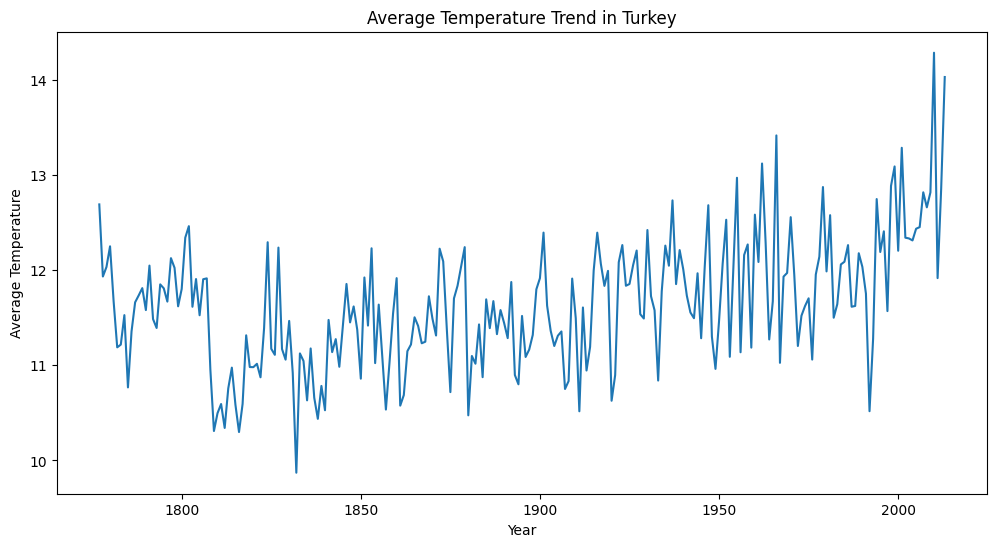

In [21]:
import matplotlib.pyplot as plt

# Convert to Pandas DataFrame for plotting
# Using df_with_year, as it contains both 'Year' and 'Country'
pdf = df_with_year.filter(df_with_year.Country == "Turkey").toPandas()

# The Year column is probably string type, convert it to integer for sorting and plotting
pdf["Year"] = pdf["Year"].astype(int)

# Sort by year for consistent plotting
pdf = pdf.sort_values(by="Year")

# Aggregate average temperature per year (if not already aggregated)
pdf = pdf.groupby("Year")["AverageTemperature"].mean().reset_index()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(pdf["Year"], pdf["AverageTemperature"])
plt.title("Average Temperature Trend in Turkey")
plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.show()

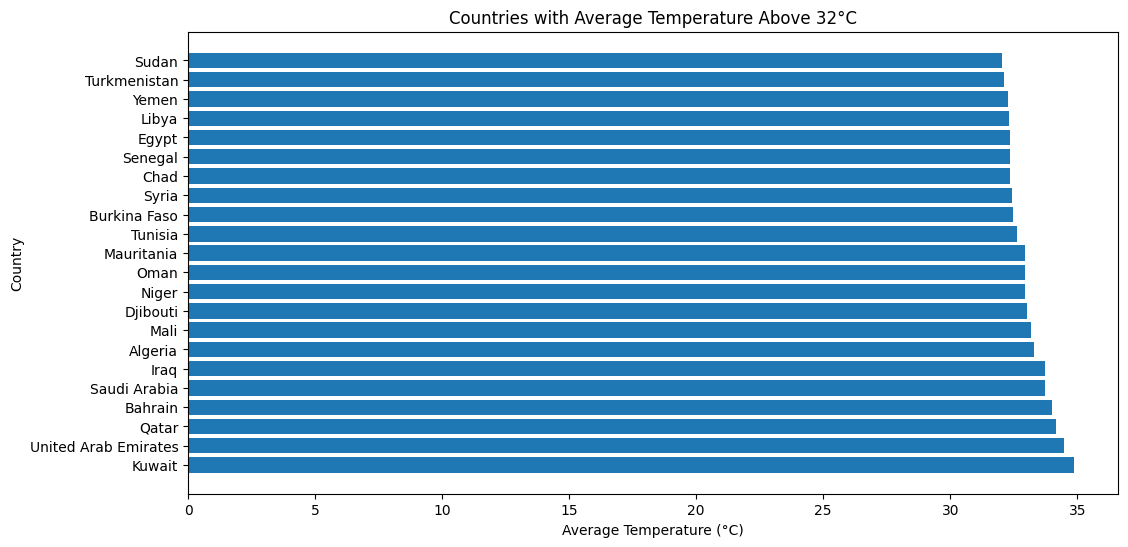

In [22]:
from pyspark.sql.functions import avg

# Filter for temperatures above 25 degrees
high_temp_df = df_with_year.filter(df_with_year['AverageTemperature'] > 32)

# Calculate average temperature for each country
avg_temp_high_countries = high_temp_df.groupBy('Country').agg(avg('AverageTemperature').alias('AvgTemp'))

# Convert to Pandas DataFrame for plotting
pdf = avg_temp_high_countries.toPandas()

# Sort the DataFrame for better visualization
pdf = pdf.sort_values(by='AvgTemp', ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
plt.barh(pdf['Country'], pdf['AvgTemp'])
plt.title('Countries with Average Temperature Above 32°C')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Country')
plt.show()

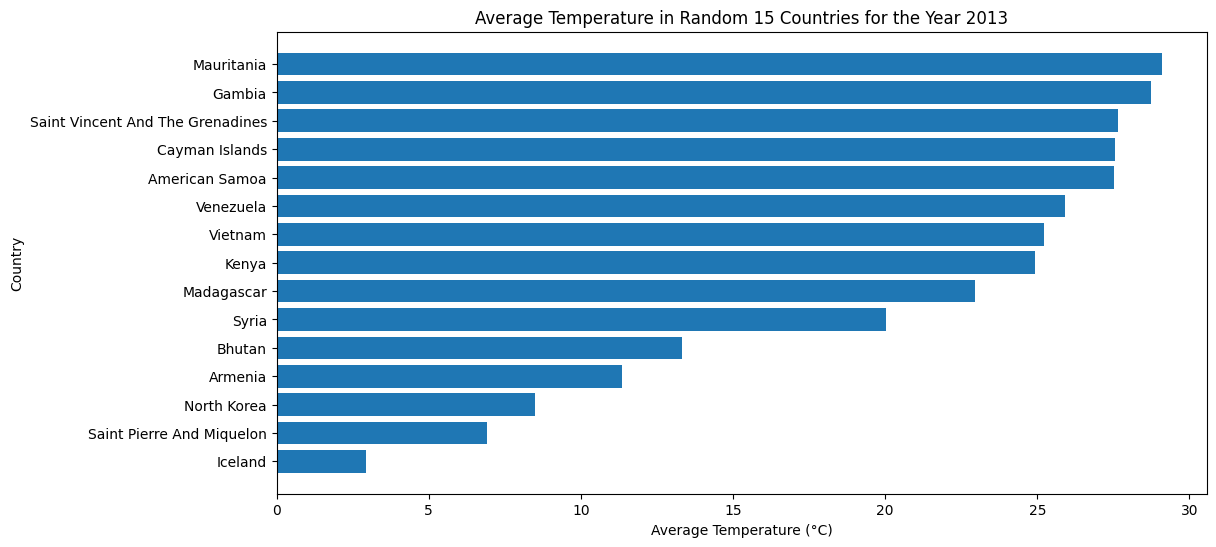

In [23]:
from pyspark.sql.functions import avg
import random

# Identify the last year in the dataset
last_year = df_with_year.agg({'Year': 'max'}).collect()[0][0]

# Filter the dataset for the last year
last_year_df = df_with_year.filter(df_with_year['Year'] == last_year)

# Calculate the average temperature for each country for the last year
avg_temp_last_year = last_year_df.groupBy('Country').agg(avg('AverageTemperature').alias('AvgTemp'))

# Convert to Pandas DataFrame for further processing
pdf = avg_temp_last_year.toPandas()

# Randomly select 15 countries
random_countries = random.sample(pdf['Country'].tolist(), 15)
pdf_filtered = pdf[pdf['Country'].isin(random_countries)]

# Sort the DataFrame for better visualization
pdf_filtered = pdf_filtered.sort_values(by='AvgTemp', ascending=True)

# Plotting
plt.figure(figsize=(12, 6))
plt.barh(pdf_filtered['Country'], pdf_filtered['AvgTemp'])
plt.title(f'Average Temperature in Random 15 Countries for the Year {last_year}')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Country')
plt.show()